# Loan Detector

## Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier  # <-- Added
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

## Importing Data

In [2]:
df_risk = pd.read_csv('raw_data/Loan_default.csv')
df_AM = pd.read_csv('raw_data/Loan_approval.csv')
df_credit = pd.read_csv('raw_data/UCI.csv')

df_risk.info()
df_AM.info()
df_credit.info()

df_AM.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST100000,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1


## Cleaning Data

In [3]:
df_AM.isnull().sum()

customer_id                0
age                        0
occupation_status          0
years_employed             0
annual_income              0
credit_score               0
credit_history_years       0
savings_assets             0
current_debt               0
defaults_on_file           0
delinquencies_last_2yrs    0
derogatory_marks           0
product_type               0
loan_intent                0
loan_amount                0
interest_rate              0
debt_to_income_ratio       0
loan_to_income_ratio       0
payment_to_income_ratio    0
loan_status                0
dtype: int64

In [4]:
df_AM['loan_intent'].unique()

array(['Business', 'Home Improvement', 'Debt Consolidation', 'Education',
       'Personal', 'Medical'], dtype=object)

In [5]:
# 1. One-Hot Encoding
df_risk = pd.get_dummies(df_risk, columns=['LoanPurpose'], dtype=int)
# pd.get_dummies automatically drops 'product_type' and 'loan_intent'
df_AM = pd.get_dummies(df_AM, columns=['product_type', 'loan_intent'], dtype=int)

# 2. Ordinal Mappings (df_risk)
mar_map = {'Single': 0, 'Married': 1, 'Divorced': 2}
df_risk['MaritalStatusCode'] = df_risk['MaritalStatus'].map(mar_map)

edu_map = {"High School": 0, "Bachelor's": 1, "Master's": 2, "PhD": 3}
df_risk['EducationCode'] = df_risk['Education'].map(edu_map)

Emp_map = {"Unemployed": 0, "Part-time": 1, "Self-employed": 2, "Full-time": 3}
df_risk['EmploymentCode'] = df_risk['EmploymentType'].map(Emp_map)

# Ordinal Mappings (df_AM)
occ_map = {'Student': 0, 'Self-Employed': 1, 'Employed': 2}
df_AM['occupation_code'] = df_AM['occupation_status'].map(occ_map)

# 3. Binary Encoding via .cat.codes
df_risk['HasMortgageCode'] = df_risk['HasMortgage'].astype('category').cat.codes
df_risk['HasDependentsCode'] = df_risk['HasDependents'].astype('category').cat.codes
df_risk['HasCoSignerCode'] = df_risk['HasCoSigner'].astype('category').cat.codes

# 4. Drop original string columns
df_risk.drop(columns=['MaritalStatus', 'Education', 'EmploymentType', 'HasMortgage', 'HasDependents', 'HasCoSigner'], inplace=True)
df_AM.drop(columns=['occupation_status'], inplace=True)  # <-- Fixed here

# Feature Engineering
df_risk['LTI'] = df_risk['LoanAmount'] / df_risk['Income']
df_risk['MonthlyDebtRatio'] = (df_risk['Income'] / 12) * df_risk['DTIRatio']
df_risk['InterestBurden'] = df_risk['LoanAmount'] * (df_risk['InterestRate'] / 100)

In [6]:
df_risk.isnull().sum()

LoanID                   0
Age                      0
Income                   0
LoanAmount               0
CreditScore              0
MonthsEmployed           0
NumCreditLines           0
InterestRate             0
LoanTerm                 0
DTIRatio                 0
Default                  0
LoanPurpose_Auto         0
LoanPurpose_Business     0
LoanPurpose_Education    0
LoanPurpose_Home         0
LoanPurpose_Other        0
MaritalStatusCode        0
EducationCode            0
EmploymentCode           0
HasMortgageCode          0
HasDependentsCode        0
HasCoSignerCode          0
LTI                      0
MonthlyDebtRatio         0
InterestBurden           0
dtype: int64

## General Analysis

In [6]:
df_risk.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default,...,LoanPurpose_Other,MaritalStatusCode,EducationCode,EmploymentCode,HasMortgageCode,HasDependentsCode,HasCoSignerCode,LTI,MonthlyDebtRatio,InterestBurden
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,...,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128,...,0.199391,1.000082,1.496235,1.498122,0.500014,0.500268,0.500108,2.177480,3439.083029,17203.156130
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379,...,0.399544,0.816051,1.117212,1.117357,0.500001,0.500001,0.500001,2.178357,2393.724010,13581.842064
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.033749,125.150000,106.615600
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.803628,1485.260000,6064.462100
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000,...,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.546720,2842.843333,13628.926000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000,...,0.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,2.671744,4941.755417,25493.196650
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000,...,1.000000,2.000000,3.000000,3.000000,1.000000,1.000000,1.000000,16.532460,11244.375000,62461.000000


In [7]:
df_AM.describe()

,age,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,...,product_type_Credit Card,product_type_Line of Credit,product_type_Personal Loan,loan_intent_Business,loan_intent_Debt Consolidation,loan_intent_Education,loan_intent_Home Improvement,loan_intent_Medical,loan_intent_Personal,occupation_code
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.957060,7.454868,50062.892040,643.614820,8.168274,3595.619400,14290.442220,0.053480,0.55464,0.147640,...,0.449100,0.200440,0.350460,0.149380,0.098340,0.20268,0.149060,0.151960,0.248580,1.602420
std,11.118603,7.612097,32630.501014,64.731518,7.207552,13232.399398,13243.757493,0.224991,0.84505,0.412996,...,0.497407,0.400334,0.477119,0.356466,0.297777,0.40200,0.356151,0.358986,0.432194,0.658421
min,18.000000,0.000000,15000.000000,348.000000,0.000000,0.000000,60.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,26.000000,1.300000,27280.500000,600.000000,2.000000,130.000000,5581.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000
50%,35.000000,4.900000,41607.500000,643.000000,6.100000,568.000000,10385.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,2.000000
75%,43.000000,11.400000,62723.250000,687.000000,12.600000,2271.000000,18449.250000,0.000000,1.00000,0.000000,...,1.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,2.000000
max,70.000000,39.900000,250000.000000,850.000000,30.000000,300000.000000,163344.000000,1.000000,9.00000,4.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,2.000000


In [7]:
df_risk.groupby('CreditScore').agg({'CreditScore': 'count'})

,CreditScore
CreditScore,
300,484
301,460
302,451
303,489
304,456
...,...
845,438
846,437
847,450


## Correlation Matrix

In [10]:
df_risk.corr(numeric_only=True)
corr_matrix = df_risk.corr(numeric_only=True)
print(corr_matrix)

                            Age    Income  LoanAmount  CreditScore  \
Age                    1.000000 -0.001244   -0.002213    -0.000548   
Income                -0.001244  1.000000   -0.000865    -0.001430   
LoanAmount            -0.002213 -0.000865    1.000000     0.001261   
CreditScore           -0.000548 -0.001430    0.001261     1.000000   
MonthsEmployed        -0.000341  0.002675    0.002817     0.000613   
NumCreditLines        -0.000890 -0.002016    0.000794     0.000016   
InterestRate          -0.001127 -0.002303   -0.002291     0.000436   
LoanTerm               0.000263 -0.000998    0.002538     0.001130   
DTIRatio              -0.004689  0.000205    0.001122    -0.001039   
Default               -0.167783 -0.099119    0.086659    -0.034166   
LoanPurpose_Auto       0.001604  0.000115    0.001964     0.000978   
LoanPurpose_Business  -0.003104  0.005124   -0.003093    -0.000638   
LoanPurpose_Education -0.002300 -0.003610    0.000472    -0.003306   
LoanPurpose_Home    

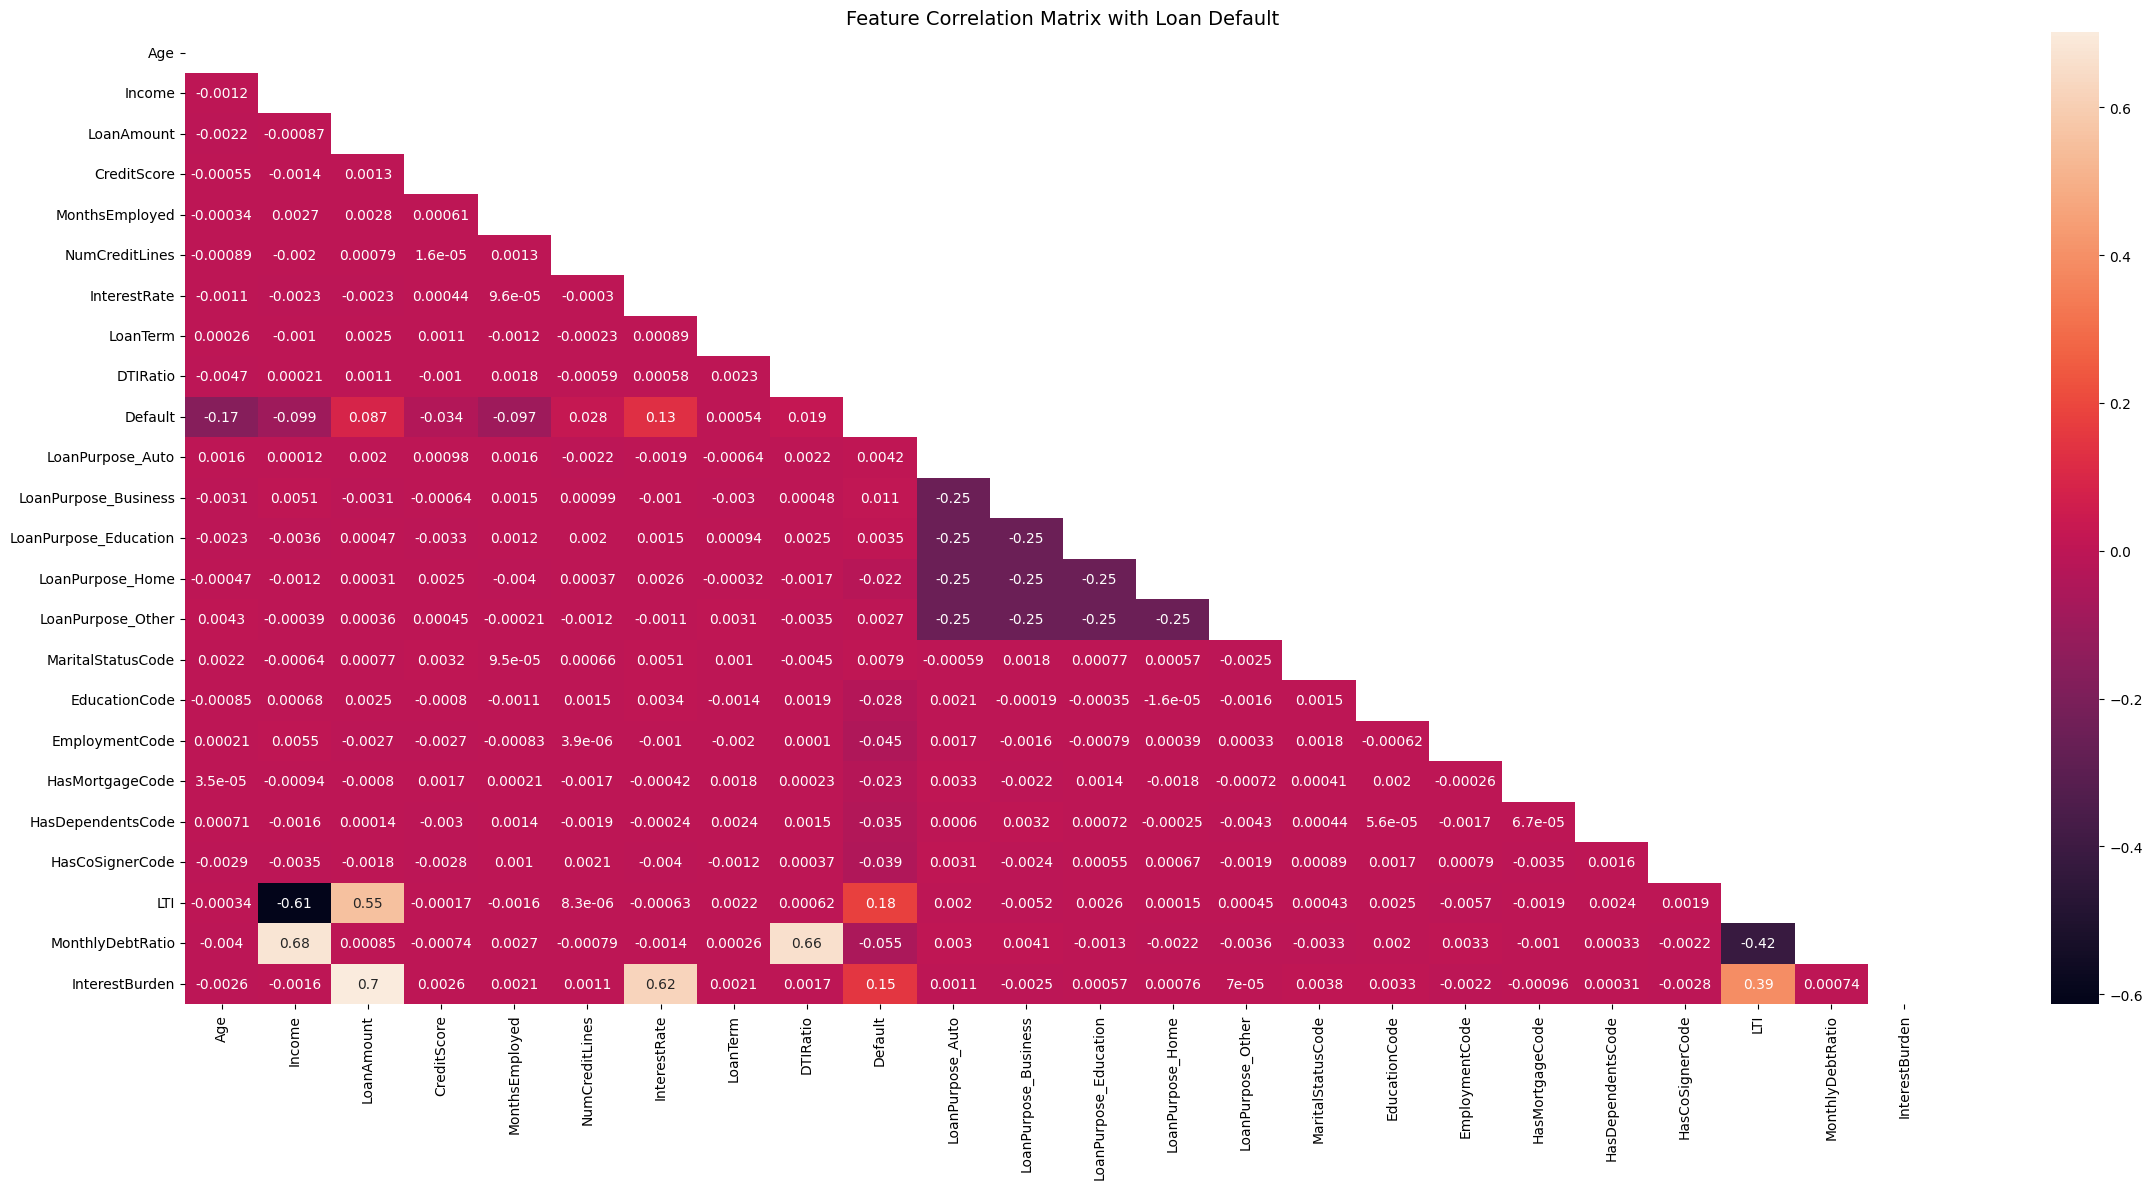

In [11]:

plt.figure(figsize=(24,12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True)
plt.title("Feature Correlation Matrix with Loan Default", fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
df_AM.corr(numeric_only=True)
corr_matrix_AM = df_AM.corr(numeric_only=True)
print(corr_matrix_AM)

                                     age  years_employed  annual_income  \
age                             1.000000        0.626840       0.264814   
years_employed                  0.626840        1.000000       0.235926   
annual_income                   0.264814        0.235926       1.000000   
credit_score                    0.369271        0.235266       0.185058   
credit_history_years            0.636136        0.404618       0.164144   
savings_assets                  0.177699        0.129377       0.203323   
current_debt                    0.179684        0.161998       0.698170   
defaults_on_file               -0.063810       -0.041415      -0.038113   
delinquencies_last_2yrs        -0.101463       -0.063597      -0.051635   
derogatory_marks               -0.098710       -0.065559      -0.044766   
loan_amount                     0.172352        0.185206       0.511129   
interest_rate                  -0.187963       -0.123444      -0.093371   
debt_to_income_ratio     

## Correlation just on Loan Defaults

In [10]:
default_corr = corr_matrix["Default"].drop("Default").sort_values()
print(default_corr)

Age                     -0.167783
Income                  -0.099119
MonthsEmployed          -0.097374
MonthlyDebtRatio        -0.055317
EmploymentCode          -0.044534
HasCoSignerCode         -0.039109
HasDependentsCode       -0.034678
CreditScore             -0.034166
EducationCode           -0.028282
HasMortgageCode         -0.022856
LoanPurpose_Home        -0.021564
LoanTerm                 0.000545
LoanPurpose_Other        0.002737
LoanPurpose_Education    0.003512
LoanPurpose_Auto         0.004181
MaritalStatusCode        0.007902
LoanPurpose_Business     0.011162
DTIRatio                 0.019236
NumCreditLines           0.028330
LoanAmount               0.086659
InterestRate             0.131273
InterestBurden           0.150401
LTI                      0.178963
Name: Default, dtype: float64


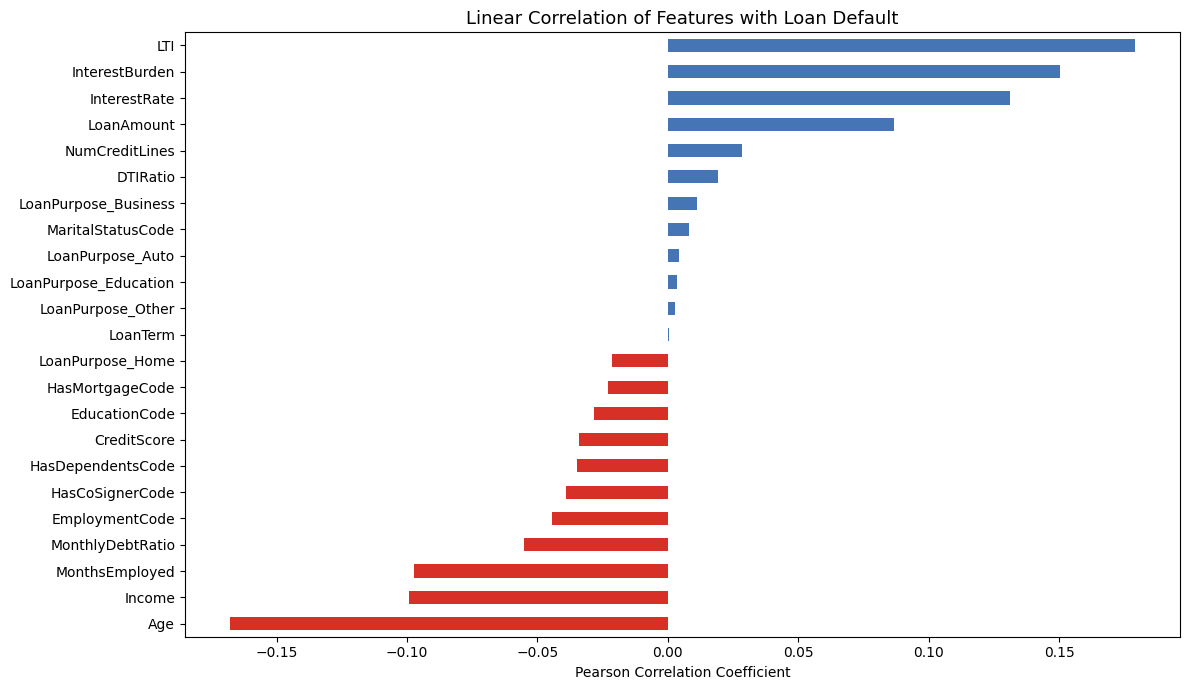

In [11]:
plt.figure(figsize=(12, 7))
colors = ["#d73027" if x < 0 else "#4575b4" for x in default_corr]
default_corr.plot(kind="barh", color=colors)
plt.title("Linear Correlation of Features with Loan Default", fontsize=13)
plt.xlabel("Pearson Correlation Coefficient")
plt.tight_layout()
plt.show()

In [13]:
default_corr_AM = corr_matrix_AM["Default"].drop("Default").sort_values()
print(default_corr_AM)

KeyError: 'Default'

## Covariance Matrix

In [12]:
cov_matrix=df_risk.cov(numeric_only=True)
print(cov_matrix)

                               Age        Income    LoanAmount   CreditScore  \
Age                     224.707847 -7.266333e+02 -2.349755e+03     -1.305749   
Income                 -726.633252  1.518116e+09 -2.388444e+06  -8856.434459   
LoanAmount            -2349.755323 -2.388444e+06  5.018406e+09  14197.937653   
CreditScore              -1.305749 -8.856434e+03  1.419794e+04  25250.438819   
MonthsEmployed           -0.177287  3.610577e+03  6.912970e+03      3.373593   
NumCreditLines           -0.014899 -8.775894e+01  6.286151e+01      0.002847   
InterestRate             -0.112154 -5.956101e+02 -1.077125e+03      0.459933   
LoanTerm                  0.066988 -6.599837e+02  3.050938e+03      3.048022   
DTIRatio                 -0.016232  1.848896e+00  1.836089e+01     -0.038134   
Default                  -0.805790 -1.237303e+03  1.966808e+03     -1.739399   
LoanPurpose_Auto          0.009599  1.791048e+00  5.556254e+01      0.062040   
LoanPurpose_Business     -0.018646  7.99

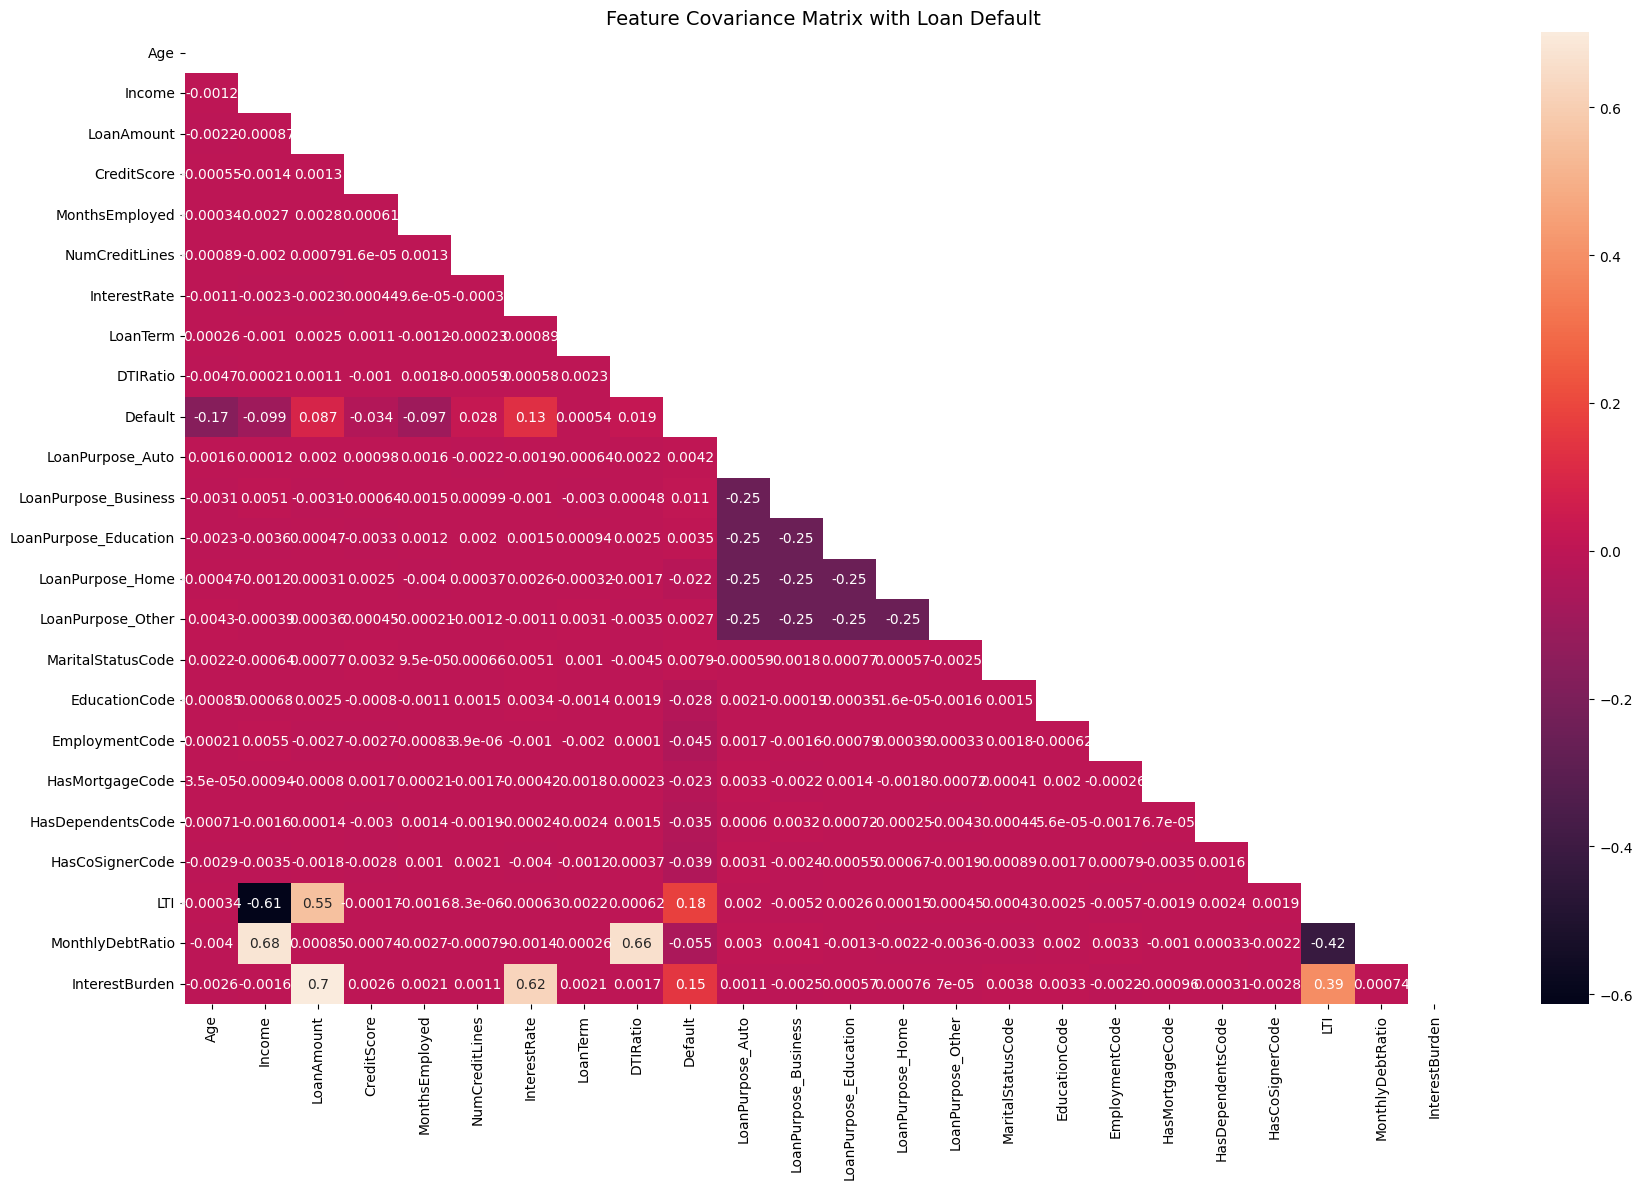

In [13]:
plt.figure(figsize=(18,12))
mask = np.triu(np.ones_like(cov_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True)
plt.title("Feature Covariance Matrix with Loan Default", fontsize=14)
plt.tight_layout()
plt.show()

## Covariance for Defaults (Not significant)

In [14]:
default_cov = cov_matrix["Default"].drop("Default").sort_values()
print(default_cov)

Income                  -1237.302790
MonthlyDebtRatio          -42.422210
CreditScore                -1.739399
MonthsEmployed             -1.080754
Age                        -0.805790
EmploymentCode             -0.015942
EducationCode              -0.010123
HasCoSignerCode            -0.006265
HasDependentsCode          -0.005555
HasMortgageCode            -0.003661
LoanPurpose_Home           -0.002768
LoanPurpose_Other           0.000350
LoanPurpose_Education       0.000450
LoanPurpose_Auto            0.000535
DTIRatio                    0.001423
LoanPurpose_Business        0.001433
MaritalStatusCode           0.002066
LoanTerm                    0.002961
NumCreditLines              0.010138
LTI                         0.124899
InterestRate                0.279110
InterestBurden            654.447590
LoanAmount               1966.807516
Name: Default, dtype: float64


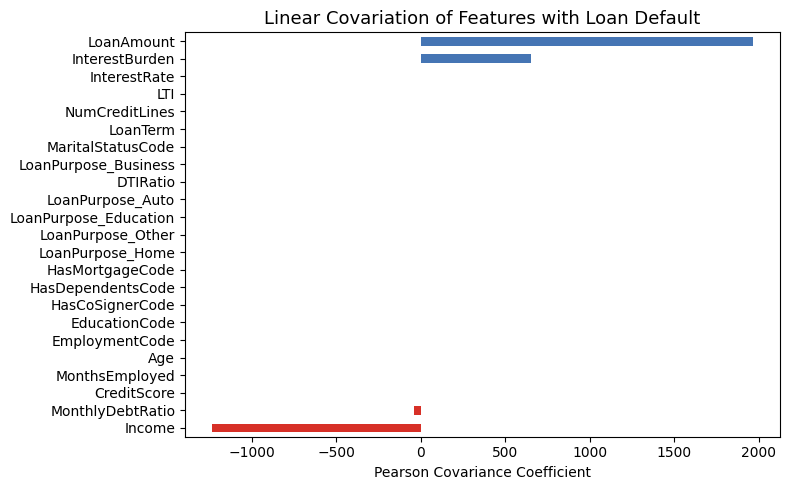

In [15]:
plt.figure(figsize=(8, 5))
colors = ["#d73027" if x < 0 else "#4575b4" for x in default_cov]
default_cov.plot(kind="barh", color=colors)
plt.title("Linear Covariation of Features with Loan Default", fontsize=13)
plt.xlabel("Pearson Covariance Coefficient")
plt.tight_layout()
plt.show()

## Modeling

In [16]:
X = df_risk.drop(columns=['LoanID', 'Default'])
y = df_risk['Default']

print("Shape:", X.shape, "| Default rate:", round(y.mean(), 4))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale for the linear model (tree models don't need this)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Shape: (255347, 23) | Default rate: 0.1161


## Baseline Logistic Regression

In [21]:
logreg = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
logreg.fit(X_train_s, y_train)

proba_lr = logreg.predict_proba(X_test_s)[:, 1]
pred_lr = logreg.predict(X_test_s)

print(f"ROC-AUC: {roc_auc_score(y_test, proba_lr):.4f}   PR-AUC: {average_precision_score(y_test, proba_lr):.4f}")
print(classification_report(y_test, pred_lr, digits=3))
print("Confusion matrix [[TN, FP],[FN, TP]]:")
print(confusion_matrix(y_test, pred_lr))

ROC-AUC: 0.7603   PR-AUC: 0.3336
              precision    recall  f1-score   support

           0      0.945     0.689     0.797     45139
           1      0.227     0.696     0.342      5931

    accuracy                          0.689     51070
   macro avg      0.586     0.692     0.570     51070
weighted avg      0.862     0.689     0.744     51070

Confusion matrix [[TN, FP],[FN, TP]]:
[[31083 14056]
 [ 1804  4127]]


## Random Forest Model

In [24]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=20,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

proba_rf = rf.predict_proba(X_test)[:, 1]
pred_rf = rf.predict(X_test)

print(f"ROC-AUC: {roc_auc_score(y_test, proba_rf):.4f}   PR-AUC: {average_precision_score(y_test, proba_rf):.4f}")
print(classification_report(y_test, pred_rf, digits=3))
print("Confusion matrix [[TN, FP],[FN, TP]]:")
print(confusion_matrix(y_test, pred_rf))

ROC-AUC: 0.7537   PR-AUC: 0.3226
              precision    recall  f1-score   support

           0      0.934     0.782     0.852     45139
           1      0.260     0.581     0.359      5931

    accuracy                          0.759     51070
   macro avg      0.597     0.682     0.605     51070
weighted avg      0.856     0.759     0.794     51070

Confusion matrix [[TN, FP],[FN, TP]]:
[[35321  9818]
 [ 2484  3447]]


In [25]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances.head(15))

Age                 0.218908
InterestRate        0.116999
LTI                 0.115613
InterestBurden      0.108619
MonthsEmployed      0.092576
Income              0.079744
LoanAmount          0.052843
MonthlyDebtRatio    0.042678
CreditScore         0.040651
DTIRatio            0.030913
EmploymentCode      0.016951
NumCreditLines      0.012267
EducationCode       0.012206
LoanTerm            0.010594
HasCoSignerCode     0.010090
dtype: float64
